In [1]:
import torch
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
import random
import numpy as np
from PIL import Image, ImageFilter
from PIL import ImageDraw, ImageEnhance
import random
import yaml
import os
from torch.utils.data import Dataset


In [2]:

class RandomGaussianNoise:
    def __init__(self, mean=0., std=0.01, p=0.3):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            return tensor + noise
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std}, p={self.p})"

class RandomGaussianBlur:
    def __init__(self, radius_min=0.1, radius_max=0.5):
        self.radius_min = radius_min
        self.radius_max = radius_max

    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius))


class RandomShadow:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        shadow = Image.new('L', img.size, 0)
        draw = ImageDraw.Draw(shadow)

        for _ in range(random.randint(1, 3)):
            x1 = random.randint(0, img.width // 2)
            y1 = random.randint(0, img.height)
            x2 = random.randint(img.width // 2, img.width)
            y2 = random.randint(0, img.height)
            x0, x1_sorted = sorted([x1, x2])
            y0, y1_sorted = sorted([y1, y2])
            draw.ellipse([x0, y0, x1_sorted, y1_sorted], fill=random.randint(60, 120))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=random.uniform(10, 30)))

        shadow = shadow.convert("RGB")
        shadow = ImageEnhance.Brightness(shadow).enhance(0.6)
        img = Image.blend(img, shadow, alpha=0.5)

        return img


class RandomBlackLines:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img):
        if random.random() > self.p:
            return img

        draw = ImageDraw.Draw(img)
        num_lines = random.randint(1, self.max_lines)

        for _ in range(num_lines):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line((x1, y1, x2, y2), fill=(0, 0, 0), width=thickness)

        return img
    
random_augmentations = [
    T.RandomRotation(30),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomPerspective(distortion_scale=0.5, p=1.0),
    RandomGaussianBlur(),
    RandomShadow(p=0.7),
    RandomBlackLines(p=0.5, max_lines=5, max_thickness=4),
]

class RandomSubsetTransform:
    def __init__(self, transforms, num_choices=2):
        self.transforms = transforms
        self.num_choices = num_choices

    def __call__(self, img):
        chosen_transforms = random.sample(self.transforms, self.num_choices)
        for t in chosen_transforms:
            img = t(img)
        return img

train_transform_balanced = T.Compose([
    T.RandomResizedCrop(150),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.2),
    RandomSubsetTransform(random_augmentations, num_choices=2),
    T.ToTensor(),
    RandomGaussianNoise(0., 0.02, p=0.3),
    T.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [3]:
class ChocolateCutPasteDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None, cutpaste_p=0.5):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        self.transform = transform
        self.cutpaste_p = cutpaste_p

    def __len__(self):
        return len(self.image_files)

    def load_labels(self, label_path, img_width, img_height):
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, w, h = map(float, line.strip().split())
                x1 = int((x - w / 2) * img_width)
                y1 = int((y - h / 2) * img_height)
                x2 = int((x + w / 2) * img_width)
                y2 = int((y + h / 2) * img_height)
                boxes.append((int(cls), x1, y1, x2, y2))
        return boxes

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        image = Image.open(img_path).convert("RGB")
        width, height = image.size
        boxes = self.load_labels(label_path, width, height)

        if random.random() < self.cutpaste_p and len(boxes) > 0:
            donor_idx = random.randint(0, len(self.image_files) - 1)
            donor_name = self.image_files[donor_idx]
            donor_img_path = os.path.join(self.image_dir, donor_name)
            donor_label_path = os.path.join(self.label_dir, donor_name.replace(".jpg", ".txt"))

            donor_img = Image.open(donor_img_path).convert("RGB")
            donor_width, donor_height = donor_img.size
            donor_boxes = self.load_labels(donor_label_path, donor_width, donor_height)

            if len(donor_boxes) > 0:
                cls, x1, y1, x2, y2 = random.choice(donor_boxes)
                donor_crop = donor_img.crop((x1, y1, x2, y2))

                # Clip if too big
                crop_w, crop_h = x2 - x1, y2 - y1
                if crop_w < width and crop_h < height:
                    paste_x = random.randint(0, width - crop_w)
                    paste_y = random.randint(0, height - crop_h)

                    image.paste(donor_crop, (paste_x, paste_y))

                    new_box = (
                        cls,
                        paste_x,
                        paste_y,
                        paste_x + crop_w,
                        paste_y + crop_h
                    )
                    boxes.append(new_box)

        # Apply full augmentation chain
        if self.transform:
            image = self.transform(image)

        boxes_xyxy = [b[1:] for b in boxes]
        labels = [b[0] for b in boxes]

        target = {
            "boxes": torch.tensor(boxes_xyxy, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return image, target


In [4]:
dataset = ChocolateCutPasteDataset(
    image_dir="/Users/lunnet_1/Downloads/FullDataset/train/images",
    label_dir="/Users/lunnet_1/Downloads/FullDataset/train/labels",
    transform=train_transform_balanced,
    cutpaste_p=0.5 
)

loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)


Below some extra code to visualize

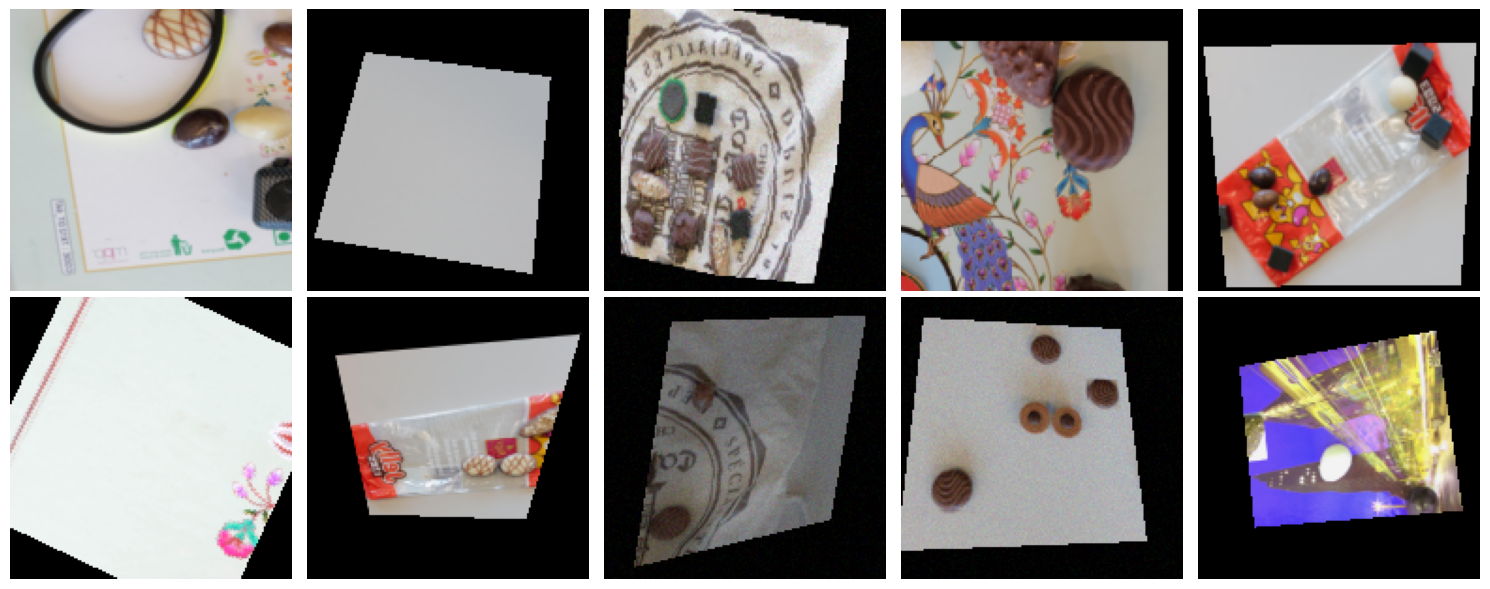

In [5]:
# Visualize some augmented images

import matplotlib.pyplot as plt
import torch

def imshow_grid(images, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        img = images[i].clone().detach().permute(1, 2, 0)
        img = img * 0.5 + 0.5  # unnormalize
        img = img.clamp(0, 1)
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

images = []
for _ in range(10):
    idx = torch.randint(len(dataset), (1,)).item()
    sample_img, _ = dataset[idx]
    images.append(sample_img)

imshow_grid(images, rows=2, cols=5)


In [6]:
# Visualize Random Shadow effect

import matplotlib.pyplot as plt
from PIL import Image

# Load a sample image (from your dataset or any local image)
original_img, _ = dataset[0]  # original image from dataset
original_pil = Image.open(dataset.samples[0][0])  # load as PIL for shadow demo

# Apply the RandomShadow transformation
shadow_transform = RandomShadow(p=1.0)  # force shadow for demo
shadow_img = shadow_transform(original_pil)

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(original_pil)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(shadow_img)
axs[1].set_title("With Random Shadow")
axs[1].axis("off")

plt.tight_layout()
plt.show()


AttributeError: 'ChocolateCutPasteDataset' object has no attribute 'samples'